# vizcraft — Skyline & Dumbbell

My two best charts from the **tallest-buildings** dataset, rendered with the
zero-dependency [`vizcraft`](https://github.com/simran587/visualization) library.

Run the cells top to bottom (**Runtime → Run all**).

## 1. Install vizcraft (pip)

Installs straight from the GitHub branch. If the repo is **private**, either
make it public or append a token to the URL (`git+https://<TOKEN>@github.com/...`).

In [22]:
!pip install -q "git+https://github.com/simran587/visualization.git@claude/visualization-library-dataset-ei5m7t"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Load the dataset and preview the head

In [23]:
import vizcraft as vc
from IPython.display import SVG, display

data = vc.load_tallest_buildings()
print(len(data), 'buildings ·', data.columns)
data.head()      # first 5 rows, rendered as a table

31 buildings · ['rank', 'building', 'city', 'country', 'height_m', 'height_ft', 'year_completed', 'floors', 'use_type']


Dataset(rows=5, columns=['rank', 'building', 'city', 'country', 'height_m', 'height_ft', 'year_completed', 'floors', 'use_type'])

## 3. Skyline — the 15 tallest, to scale

Each building is drawn as its own recognizable silhouette, scaled to its true
height, with Burj Khalifa highlighted.

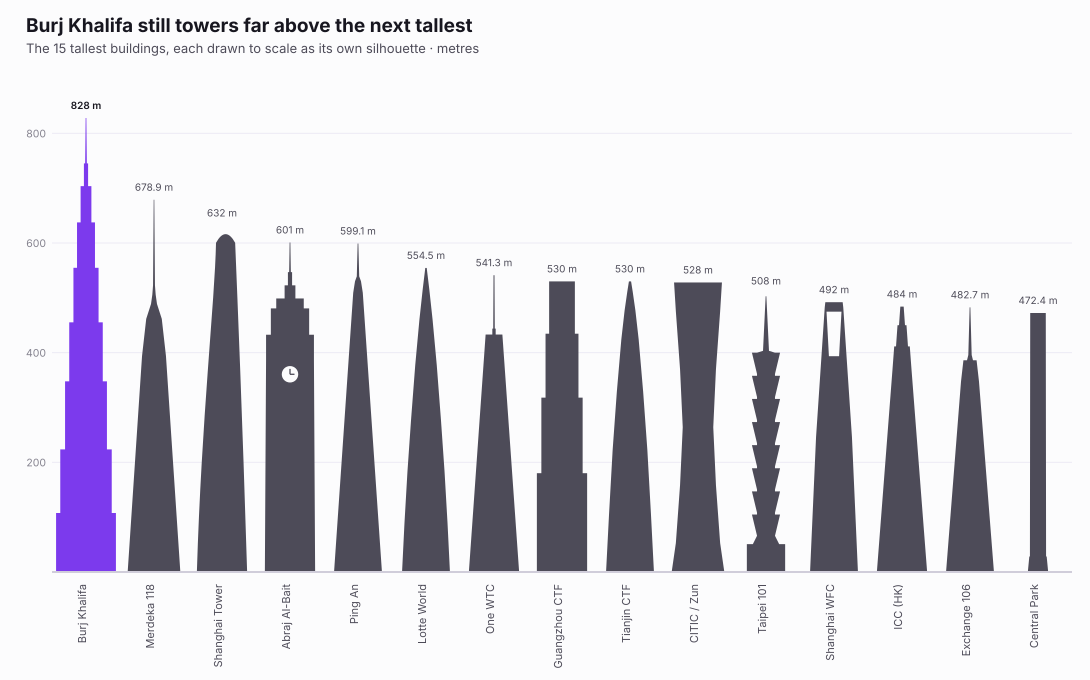

In [24]:
top = data.top('height_m', 15)

skyline = vc.skyline_chart(
    top.column('building'), top.column('height_m'),
    title='Burj Khalifa still towers far above the next tallest',
    subtitle='The 15 tallest buildings, each drawn to scale as its own silhouette \u00b7 metres',
    highlight='Burj Khalifa', unit=' m',
)
skyline.save('skyline.svg')   # also writes an SVG file
display(SVG(skyline.to_string()))

## 4. Dumbbell — each country's shortest-to-tallest range

A horizontal dumbbell (open \u25cb = shortest, filled \u25cf = tallest) with the UAE
\u2014 the widest range \u2014 highlighted.

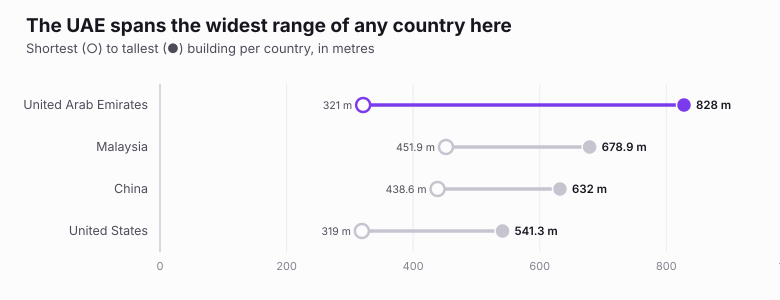

In [25]:
cats, lo, hi = [], [], []
for country, ds in data.groups('country').items():
    heights = ds.column('height_m')
    if len(heights) >= 2:
        cats.append(country); lo.append(min(heights)); hi.append(max(heights))
order = sorted(range(len(cats)), key=lambda i: hi[i], reverse=True)

dumbbell = vc.dumbbell_chart(
    [cats[i] for i in order], [lo[i] for i in order], [hi[i] for i in order],
    highlight='United Arab Emirates',
    title='The UAE spans the widest range of any country here',
    subtitle='Shortest (\u25cb) to tallest (\u25cf) building per country, in metres',
    unit=' m',
)
dumbbell.save('dumbbell.svg')
display(SVG(dumbbell.to_string()))

## 5. (Optional) dark theme

Every chart takes `theme="dark"`.

In [ ]:
display(SVG(vc.skyline_chart(
    top.column('building'), top.column('height_m'),
    title='Burj Khalifa still towers far above the next tallest',
    subtitle='At night \u00b7 metres', highlight='Burj Khalifa', unit=' m',
    theme='dark',
).to_string()))